ATIVIDADE NETFLIX - STREAMING - DIAGRAMA - CONEXÃO COM O BANCO DE DADOS

Inicialmente damos o comando *!pip install pymysql*, ele vai nos permitir conectar seu código Python a um banco de dados MySQL.

In [45]:
!pip install pymysql

Defaulting to user installation because normal site-packages is not writeable


Aqui vamos Importa a biblioteca PyMySQL

In [44]:
import pymysql

Estamos importando algumas classes específicas da biblioteca datetime

In [22]:
from datetime import date, time, datetime

Aqui vamos conectar nosso python com o mysql e vamos criar o objeto "cursor" onde irá executar os comandos SQL conexão

In [41]:
conn = pymysql.connect( host = 'localhost', user = 'root', password = 'root')
cursor = conn.cursor()

Aqui vamos criar um novo banco de dados (IF NOT EXISTS -> Vai verificar se já não existe um banco com esse nome)

In [8]:
cursor.execute('CREATE DATABASE IF NOT EXISTS streaming')

1

Aqui vamos verificar se esta ou não conectado no Bnaco de dados que acabamos de criar

In [42]:
if conn.open:
    print("Conexão ativa!")
else:
    print("Banco de dados desconectado")

Conexão ativa!


Abrir os bancos de dados já existentes 

In [11]:
cursor.execute("SHOW DATABASES;")
cursor.fetchall()

(('information_schema',),
 ('mysql',),
 ('performance_schema',),
 ('streaming',),
 ('sys',))

Selecionar o banco de dados que criamos 

In [46]:
cursor.execute("USE streaming")

0

In [47]:
cursor.execute("SELECT DATABASE();")
cursor.fetchone()

('streaming',)

Vamos criar as tabelas com os atributos

In [15]:
# Tabela Conteúdo
cursor.execute('''
CREATE TABLE IF NOT EXISTS Conteudo (
    ID_Conteudo INT AUTO_INCREMENT PRIMARY KEY,
    Título VARCHAR(255),
    Gênero VARCHAR(100),
    Ano_Lançamento INT,
    Conteudo TEXT
)
''')
print("Tabela 'Conteudo' verificada/criada.")

Tabela 'Conteudo' verificada/criada.


In [16]:
# Tabela Usuário
cursor.execute('''
CREATE TABLE IF NOT EXISTS Usuario (
    ID_Usuario INT AUTO_INCREMENT PRIMARY KEY,
    E_mail VARCHAR(255),
    Data_de_Nascimento DATE,
    Nome VARCHAR(255),
    Plano_Assinatura VARCHAR(100)
)
''')
print("Tabela 'Usuario' verificada/criada.")

Tabela 'Usuario' verificada/criada.


In [17]:
# Tabela Dispositivo
cursor.execute('''
CREATE TABLE IF NOT EXISTS Dispositivo (
    ID_Dispositivos INT AUTO_INCREMENT PRIMARY KEY,
    Tipo VARCHAR(100)
)
''')
print("Tabela 'Dispositivo' verificada/criada.")

Tabela 'Dispositivo' verificada/criada.


In [19]:
# Tabela Tempo
cursor.execute('''
CREATE TABLE IF NOT EXISTS Tempo (
    ID_Tempo INT AUTO_INCREMENT PRIMARY KEY,
    Dia_Interacao INT,
    Mes_Interacao INT,
    Ano_Interacao INT,
    Hora_Interacao TIME
)
''')
print("Tabela 'Tempo' verificada/criada.")


Tabela 'Tempo' verificada/criada.


Como seguimos o modelo estrela, aqui vamos juntar as tabelas com as Foreign Keys, a tabela central 

In [20]:
# Tabela Interacao (Tabela Fato Central)
# É importante que as tabelas referenciadas (Conteudo, Tempo, Usuario, Dispositivo)
# já existam antes de criar esta tabela devido às FOREIGN KEYs.
cursor.execute('''
CREATE TABLE IF NOT EXISTS Interacao (
    ID_Interacao INT AUTO_INCREMENT PRIMARY KEY,
    FK_ID_Dispositivos INT,
    FK_ID_Conteudo INT,
    FK_ID_Usuario INT,
    FK_ID_Tempo INT,
    Tipo_Interacao VARCHAR(100),
    Duracao_Assistido INT,
    Nota_Avaliacao INT,

    FOREIGN KEY (FK_ID_Dispositivos) REFERENCES Dispositivo(ID_Dispositivos),
    FOREIGN KEY (FK_ID_Conteudo) REFERENCES Conteudo(ID_Conteudo),
    FOREIGN KEY (FK_ID_Usuario) REFERENCES Usuario(ID_Usuario),
    FOREIGN KEY (FK_ID_Tempo) REFERENCES Tempo(ID_Tempo)
)
''')
print("Tabela 'Interacao' verificada/criada.")

Tabela 'Interacao' verificada/criada.


Salvamos todas as alterações que fizemos no banco, para isso usamos o *commit*

In [21]:
conn.commit() # Salva as alterações no banco de dados
print("Todas as tabelas foram criadas/verificadas e as alterações commitadas.")


Todas as tabelas foram criadas/verificadas e as alterações commitadas.


Começamos a por informações nas tabelas que criamos (Dados fictícios) para alimentar nosso banco

In [23]:
conteudos_data = [
    ("O Último Guardião", "Fantasia", 2023, "Um herói improvável descobre seus poderes para salvar o mundo."),
    ("Código Secreto", "Suspense", 2022, "Um agente secreto precisa decifrar um código antes que seja tarde."),
    ("Chefes da Cozinha", "Documentário", 2021, "Acompanhe a vida e a arte dos maiores chefs do mundo."),
    ("Amor Além do Tempo", "Drama", 2020, "Uma história de amor que transcende as barreiras do tempo."),
    ("Robôs Rebeldes", "Ficção Científica", 2023, "Em um futuro distante, robôs desenvolvem consciência e se revoltam.")
]

print("\n--- Inserindo dados na tabela 'Conteudo' ---")
sql = "INSERT INTO Conteudo (Título, Gênero, Ano_Lançamento, Conteudo) VALUES (%s, %s, %s, %s)"
try:
    cursor.executemany(sql, conteudos_data)
    conn.commit()
    print(f"{cursor.rowcount} conteúdos inseridos com sucesso na tabela 'Conteudo'.")
except mysql.connector.Error as err:
    print(f"Erro ao inserir conteúdos: {err}")
    conn.rollback()
    raise # Re-lança o erro



--- Inserindo dados na tabela 'Conteudo' ---
5 conteúdos inseridos com sucesso na tabela 'Conteudo'.


In [24]:
tempos_data = [
    (date(2023, 10, 26).day, date(2023, 10, 26).month, date(2023, 10, 26).year, time(14, 30, 0)),
    (date(2023, 10, 26).day, date(2023, 10, 26).month, date(2023, 10, 26).year, time(20, 0, 0)),
    (date(2023, 10, 27).day, date(2023, 10, 27).month, date(2023, 10, 27).year, time(9, 15, 0)),
    (date(2023, 10, 27).day, date(2023, 10, 27).month, date(2023, 10, 27).year, time(18, 45, 0)),
    (date(2023, 10, 28).day, date(2023, 10, 28).month, date(2023, 10, 28).year, time(11, 0, 0))
]

print("\n--- Inserindo dados na tabela 'Tempo' ---")
sql = "INSERT INTO Tempo (Dia_Interacao, Mes_Interacao, Ano_Interacao, Hora_Interacao) VALUES (%s, %s, %s, %s)"
try:
    cursor.executemany(sql, tempos_data)
    conn.commit()
    print(f"{cursor.rowcount} entradas de tempo inseridas com sucesso na tabela 'Tempo'.")
except mysql.connector.Error as err:
    print(f"Erro ao inserir tempos: {err}")
    conn.rollback()
    raise



--- Inserindo dados na tabela 'Tempo' ---
5 entradas de tempo inseridas com sucesso na tabela 'Tempo'.


In [25]:
usuarios_data = [
    ("joao.silva@email.com", date(1990, 5, 10), "João Silva", "Premium"),
    ("maria.souza@email.com", date(1985, 11, 20), "Maria Souza", "Básico"),
    ("ana.costa@email.com", date(1995, 3, 25), "Ana Costa", "Premium"),
    ("pedro.gomes@email.com", date(1988, 7, 12), "Pedro Gomes", "Família"),
    ("sofia.alves@email.com", date(2000, 1, 30), "Sofia Alves", "Estudante")
]

print("\n--- Inserindo dados na tabela 'Usuario' ---")
sql = "INSERT INTO Usuario (E_mail, Data_de_Nascimento, Nome, Plano_Assinatura) VALUES (%s, %s, %s, %s)"
try:
    cursor.executemany(sql, usuarios_data)
    conn.commit()
    print(f"{cursor.rowcount} usuários inseridos com sucesso na tabela 'Usuario'.")
except mysql.connector.Error as err:
    print(f"Erro ao inserir usuários: {err}")
    conn.rollback()
    raise



--- Inserindo dados na tabela 'Usuario' ---
5 usuários inseridos com sucesso na tabela 'Usuario'.


In [26]:
dispositivos_data = [
    ("Celular Android",), # Tupla de um elemento precisa da vírgula
    ("Smart TV LG",),
    ("Tablet iOS",),
    ("Computador Desktop",),
    ("Laptop Windows",)
]

print("\n--- Inserindo dados na tabela 'Dispositivo' ---")
sql = "INSERT INTO Dispositivo (Tipo) VALUES (%s)"
try:
    cursor.executemany(sql, dispositivos_data)
    conn.commit()
    print(f"{cursor.rowcount} dispositivos inseridos com sucesso na tabela 'Dispositivo'.")
except mysql.connector.Error as err:
    print(f"Erro ao inserir dispositivos: {err}")
    conn.rollback()
    raise




--- Inserindo dados na tabela 'Dispositivo' ---
5 dispositivos inseridos com sucesso na tabela 'Dispositivo'.


Aqui inserimos os IDs de cada conteúdo, essa é a informação que conecta com a tabela central

In [30]:
cursor.execute("SELECT ID_Conteudo FROM Conteudo ORDER BY ID_Conteudo DESC LIMIT 5")
conteudos_inseridos_ids = [row[0] for row in cursor.fetchall()][::-1] # Inverte para ter na ordem original
print(f"IDs dos conteúdos inseridos: {conteudos_inseridos_ids}")

IDs dos conteúdos inseridos: [1, 2, 3, 4, 5]


In [31]:
cursor.execute("SELECT ID_Tempo FROM Tempo ORDER BY ID_Tempo DESC LIMIT 5")
tempos_inseridos_ids = [row[0] for row in cursor.fetchall()][::-1]
print(f"IDs dos tempos inseridos: {tempos_inseridos_ids}")

IDs dos tempos inseridos: [1, 2, 3, 4, 5]


In [32]:
cursor.execute("SELECT ID_Usuario FROM Usuario ORDER BY ID_Usuario DESC LIMIT 5")
usuarios_inseridos_ids = [row[0] for row in cursor.fetchall()][::-1]
print(f"IDs dos usuários inseridos: {usuarios_inseridos_ids}")

IDs dos usuários inseridos: [1, 2, 3, 4, 5]


In [33]:
cursor.execute("SELECT ID_Dispositivos FROM Dispositivo ORDER BY ID_Dispositivos DESC LIMIT 5")
dispositivos_inseridos_ids = [row[0] for row in cursor.fetchall()][::-1]
print(f"IDs dos dispositivos inseridos: {dispositivos_inseridos_ids}")

IDs dos dispositivos inseridos: [1, 2, 3, 4, 5]


In [48]:
interacoes_data = [
    (dispositivos_inseridos_ids[0], conteudos_inseridos_ids[0], usuarios_inseridos_ids[0], tempos_inseridos_ids[0],
     "Assistiu Completo", 120, 5),
    (dispositivos_inseridos_ids[1], conteudos_inseridos_ids[1], usuarios_inseridos_ids[1], tempos_inseridos_ids[1],
     "Assistiu Parcial", 45, None),
    (dispositivos_inseridos_ids[2], conteudos_inseridos_ids[2], usuarios_inseridos_ids[2], tempos_inseridos_ids[2],
     "Adicionou à Lista", None, None),
    (dispositivos_inseridos_ids[3], conteudos_inseridos_ids[3], usuarios_inseridos_ids[3], tempos_inseridos_ids[3],
     "Avaliou", None, 4),
    (dispositivos_inseridos_ids[4], conteudos_inseridos_ids[4], usuarios_inseridos_ids[4], tempos_inseridos_ids[4],
     "Iniciou", 10, None)
]

print("\n--- Inserindo dados na tabela 'Interacao' ---")
sql = """
INSERT INTO Interacao (
    FK_ID_Dispositivos, FK_ID_Conteudo, FK_ID_Usuario, FK_ID_Tempo,
    Tipo_Interacao, Duracao_Assistido, Nota_Avaliacao
) VALUES (%s, %s, %s, %s, %s, %s, %s)
"""
try:
    cursor.executemany(sql, interacoes_data)
    conn.commit()
    print(f"{cursor.rowcount} interações inseridas com sucesso na tabela 'Interacao'.")
except mysql.connector.Error as err:
    print(f"Erro ao inserir interações: {err}")
    conn.rollback()
    raise


--- Inserindo dados na tabela 'Interacao' ---
5 interações inseridas com sucesso na tabela 'Interacao'.


In [35]:
cursor.execute('SHOW DATABASES;')
cursor.fetchall()

(('information_schema',),
 ('mysql',),
 ('performance_schema',),
 ('streaming',),
 ('sys',))

Encerramos as conexões com o banco

In [49]:
cursor.close()
conn.close()

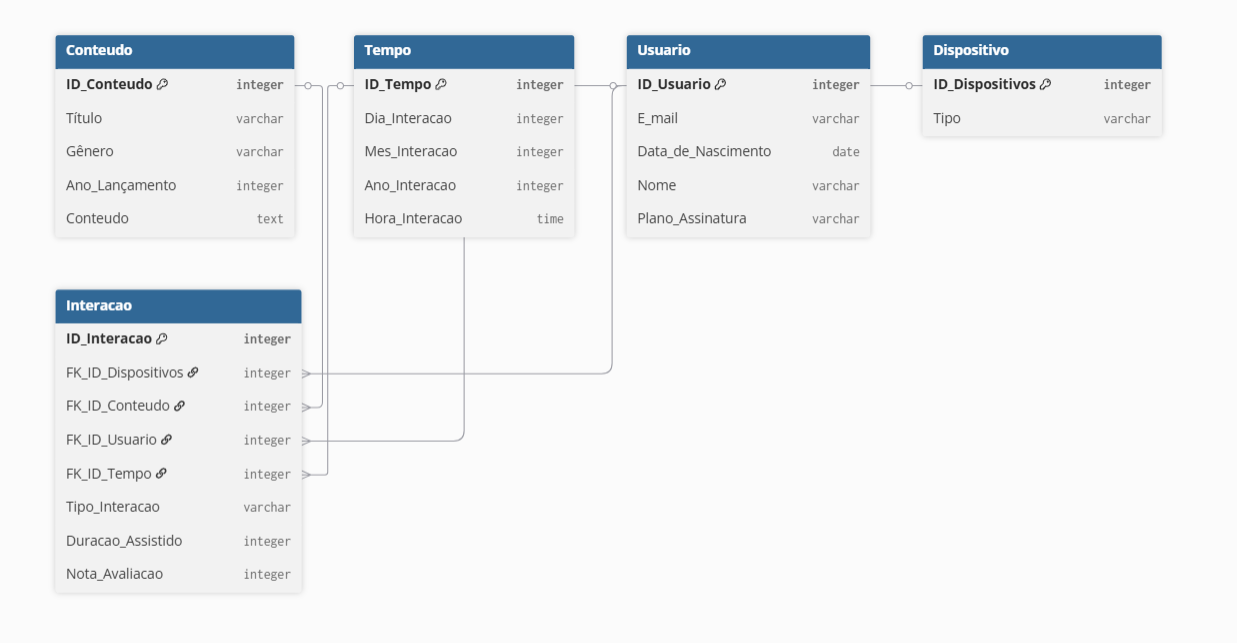

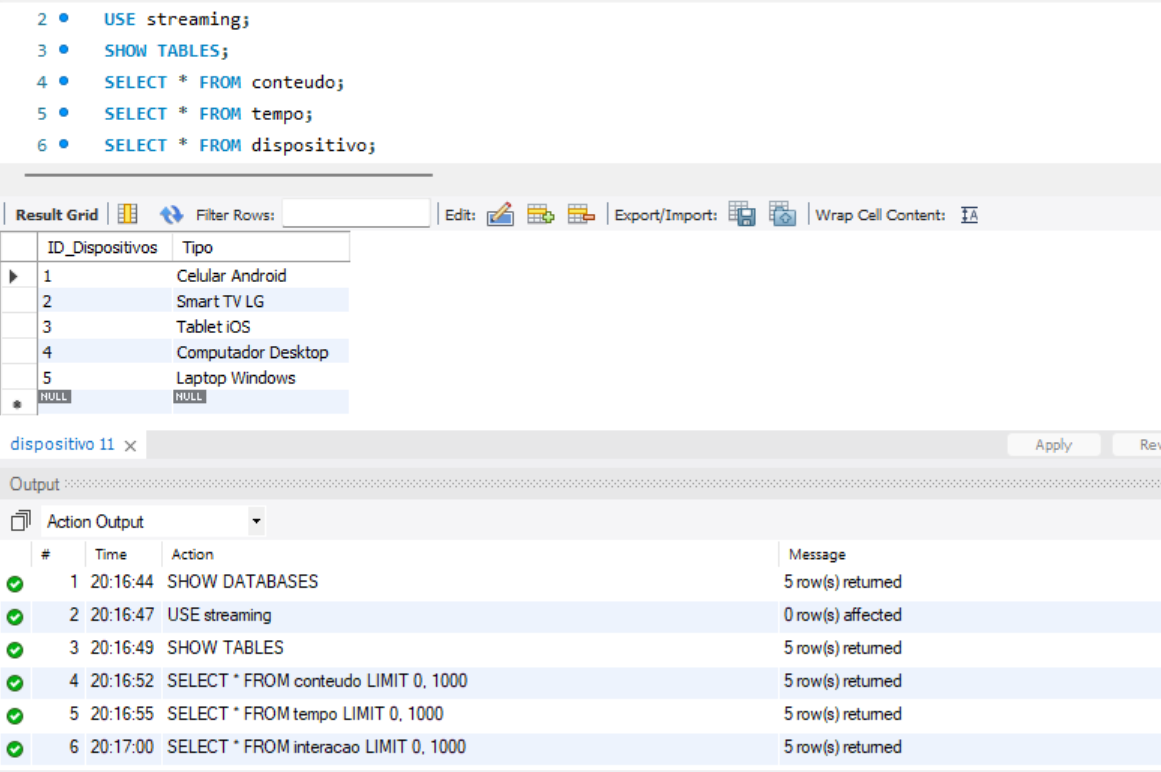